# ML Model Training & Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV,
    cross_validate
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = (
    PROJECT_ROOT /
    "data" /
    "processed"
)

ML_DIR = (
    PROCESSED_DIR /
    "ml"
)

REPORTS_DIR = (
    PROJECT_ROOT /
    "reports"
)

TABLES_DIR = (
    REPORTS_DIR /
    "tables" /
    "phase9_models"
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR = (
    PROJECT_ROOT /
    "models" /
    "phase9"
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
#frozen Phase 8 splits
train_df = pd.read_csv(
    ML_DIR / "train.csv",
    parse_dates=['time', 'target_time'],
    index_col='time'
)

validation_df = pd.read_csv(
    ML_DIR / "validation.csv",
    parse_dates=['time', 'target_time'],
    index_col='time'
)

test_df = pd.read_csv(
    ML_DIR / "test.csv",
    parse_dates=['time', 'target_time'],
    index_col='time'
)

In [4]:
feature_table = pd.read_csv(
    REPORTS_DIR /
    "tables" /
    "phase8_ml_preparation" /
    "forecast_feature_list.csv"
)

feature_columns = (
    feature_table['feature']
    .tolist()
)

In [5]:
print("Features:", len(feature_columns))

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

print(
    "Missing train features:",
    train_df[
        feature_columns
    ].isna().sum().sum()
)

Features: 55
Train: (16211, 60)
Validation: (3451, 61)
Test: (3450, 60)
Missing train features: 0


In [6]:
# x and y
TARGET = 'target_pm25_24h'

X_train = (
    train_df[
        feature_columns
    ].copy()
)

y_train = (
    train_df[
        TARGET
    ].copy()
)

X_validation = (
    validation_df[
        feature_columns
    ].copy()
)

y_validation = (
    validation_df[
        TARGET
    ].copy()
)

X_test = (
    test_df[
        feature_columns
    ].copy()
)

y_test = (
    test_df[
        TARGET
    ].copy()
)

In [7]:
print(
    X_train.shape,
    X_validation.shape,
    X_test.shape
)

(16211, 55) (3451, 55) (3450, 55)


## Metrics

In [8]:
#functions
def regression_metrics(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

In [9]:
#Forecast skill versus persistence
def add_skill_scores(
    metrics,
    baseline_metrics
):

    metrics = metrics.copy()

    metrics[
        'MAE_Skill'
    ] = (
        1
        -
        metrics['MAE']
        / baseline_metrics['MAE']
    )

    metrics[
        'RMSE_Skill'
    ] = (
        1
        -
        metrics['RMSE']
        / baseline_metrics['RMSE']
    )

    return metrics

## Time-series cross-validation

In [10]:
FORECAST_HORIZON = 24

tscv = TimeSeriesSplit(
    n_splits=5,
    gap=FORECAST_HORIZON
)

In [11]:
for fold, (
    train_idx,
    val_idx
) in enumerate(
    tscv.split(train_df),
    start=1
):

    fold_train = (
        train_df.iloc[
            train_idx
        ]
    )

    fold_validation = (
        train_df.iloc[
            val_idx
        ]
    )

    assert (
        fold_train[
            'target_time'
        ].max()
        <
        fold_validation.index.min()
    )

    print(
        f"Fold {fold}: "
        f"target overlap check passed"
    )

Fold 1: target overlap check passed
Fold 2: target overlap check passed
Fold 3: target overlap check passed
Fold 4: target overlap check passed
Fold 5: target overlap check passed


## Persistence baseline across CV folds

In [12]:
baseline_cv_rows = []

for fold, (
    train_idx,
    val_idx
) in enumerate(
    tscv.split(train_df),
    start=1
):

    fold_validation = (
        train_df.iloc[
            val_idx
        ]
    )

    y_true = (
        fold_validation[
            TARGET
        ]
    )

    y_pred = (
        fold_validation[
            'baseline_persistence'
        ]
    )

    metrics = regression_metrics(
        y_true,
        y_pred
    )

    baseline_cv_rows.append({
        'fold': fold,
        **metrics
    })


baseline_cv = pd.DataFrame(
    baseline_cv_rows
)

baseline_cv

,fold,MAE,RMSE,R2
0,1,8.282155,10.898110,0.632585
1,2,6.772751,9.132971,0.419446
2,3,5.852462,7.574388,0.360775
3,4,7.741651,10.999076,0.434196
4,5,8.045465,10.377062,0.410128


In [13]:
baseline_cv_summary = (
    baseline_cv[
        [
            'MAE',
            'RMSE',
            'R2'
        ]
    ]
    .agg([
        'mean',
        'std'
    ])
)

baseline_cv_summary.round(3)

,MAE,RMSE,R2
mean,7.339,9.796,0.451
std,1.010,1.447,0.105


## Scoring for model tuning

In [14]:
scoring = {
    'MAE':
        'neg_mean_absolute_error',

    'RMSE':
        'neg_root_mean_squared_error',

    'R2':
        'r2'
}

## Model 1: Ridge Regression

In [15]:
#Pipeling
ridge_pipeline = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),

    (
        'ridge',
        Ridge()
    )
])

In [16]:
ridge_grid = {
    'ridge__alpha': [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ]
}

In [17]:
ridge_search = GridSearchCV(
    estimator=
        ridge_pipeline,

    param_grid=
        ridge_grid,

    scoring=
        scoring,

    refit=
        'MAE',

    cv=
        tscv,

    n_jobs=-1,

    return_train_score=False
)

In [18]:
ridge_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl

In [19]:
print(
    "Best Ridge parameters:"
)

print(
    ridge_search.best_params_
)

print(
    "Best CV MAE:",
    -ridge_search.best_score_
)

Best Ridge parameters:
{'ridge__alpha': 100.0}
Best CV MAE: 8.586665727634951


## Model 2: Random Forest

In [20]:
# Model
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [21]:
rf_grid = {
    'n_estimators': [
        300
    ],

    'max_depth': [
        12,
        None
    ],

    'min_samples_leaf': [
        1,
        3,
        6
    ],

    'max_features': [
        'sqrt',
        0.7
    ]
}

In [22]:
#Tune random forest
rf_search = GridSearchCV(
    estimator=
        rf_model,

    param_grid=
        rf_grid,

    scoring=
        scoring,

    refit=
        'MAE',

    cv=
        tscv,

    n_jobs=-1,

    return_train_score=False
)

In [24]:
rf_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [12, None], 'max_features': ['sqrt', 0.7], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.2

In [25]:
print(
    "Best Random Forest parameters:"
)

print(
    rf_search.best_params_
)

print(
    "Best CV MAE:",
    -rf_search.best_score_
)

Best Random Forest parameters:
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'n_estimators': 300}
Best CV MAE: 7.574898052066776


## Model 3: HistGradientBoosting

In [26]:
hgb_model = (
    HistGradientBoostingRegressor(
        random_state=42,
        early_stopping=False
    )
)

In [27]:
hgb_grid = {
    'learning_rate': [
        0.03,
        0.07,
        0.10
    ],

    'max_iter': [
        300
    ],

    'max_leaf_nodes': [
        15,
        31
    ],

    'l2_regularization': [
        0.0,
        1.0
    ]
}

In [28]:
#Tune HistGradientBoosting
hgb_search = GridSearchCV(
    estimator=
        hgb_model,

    param_grid=
        hgb_grid,

    scoring=
        scoring,

    refit=
        'MAE',

    cv=
        tscv,

    n_jobs=-1,

    return_train_score=False
)

In [29]:
hgb_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'l2_regularization': [0.0, 1.0], 'learning_rate': [0.03, 0.07, ...], 'max_iter': [300], 'max_leaf_nodes': [15, 31]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'R2': 'r2', 'RMSE': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged::

In [30]:
print(
    "Best HGB parameters:"
)

print(
    hgb_search.best_params_
)

print(
    "Best CV MAE:",
    -hgb_search.best_score_
)

Best HGB parameters:
{'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_iter': 300, 'max_leaf_nodes': 15}
Best CV MAE: 8.273818375110718


## Comparing tuned CV results

In [31]:
#Helper for GridSearchCV results
def summarize_search(
    model_name,
    search
):

    best_idx = (
        search.best_index_
    )

    result = {
        'Model':
            model_name,

        'CV_MAE':
            -search.cv_results_[
                'mean_test_MAE'
            ][best_idx],

        'CV_MAE_SD':
            search.cv_results_[
                'std_test_MAE'
            ][best_idx],

        'CV_RMSE':
            -search.cv_results_[
                'mean_test_RMSE'
            ][best_idx],

        'CV_R2':
            search.cv_results_[
                'mean_test_R2'
            ][best_idx],

        'Best_Params':
            search.best_params_
    }

    return result

In [32]:
#Model-search summary
search_summary = pd.DataFrame([
    summarize_search(
        'Ridge',
        ridge_search
    ),

    summarize_search(
        'Random Forest',
        rf_search
    ),

    summarize_search(
        'HistGradientBoosting',
        hgb_search
    )
])

In [33]:
search_summary[
    [
        'Model',
        'CV_MAE',
        'CV_MAE_SD',
        'CV_RMSE',
        'CV_R2'
    ]
].sort_values(
    'CV_MAE'
).round(3)

,Model,CV_MAE,CV_MAE_SD,CV_RMSE,CV_R2
1,Random Forest,7.575,1.161,9.624,0.471
2,HistGradientBoosting,8.274,1.621,10.479,0.373
0,Ridge,8.587,1.415,10.682,0.333


In [34]:
#persistence CV benchmark
persistence_cv_metrics = {
    'Model':
        'Persistence_24h',

    'CV_MAE':
        baseline_cv[
            'MAE'
        ].mean(),

    'CV_MAE_SD':
        baseline_cv[
            'MAE'
        ].std(),

    'CV_RMSE':
        baseline_cv[
            'RMSE'
        ].mean(),

    'CV_R2':
        baseline_cv[
            'R2'
        ].mean()
}

In [35]:
cv_comparison = pd.concat(
    [
        pd.DataFrame([
            persistence_cv_metrics
        ]),

        search_summary[
            [
                'Model',
                'CV_MAE',
                'CV_MAE_SD',
                'CV_RMSE',
                'CV_R2'
            ]
        ]
    ],
    ignore_index=True
)

In [36]:
cv_comparison.sort_values(
    'CV_MAE'
).round(3)

,Model,CV_MAE,CV_MAE_SD,CV_RMSE,CV_R2
0,Persistence_24h,7.339,1.010,9.796,0.451
2,Random Forest,7.575,1.161,9.624,0.471
3,HistGradientBoosting,8.274,1.621,10.479,0.373
1,Ridge,8.587,1.415,10.682,0.333


## Fold-level stability of tuned models

In [37]:
#Tuned estimator dictionary
best_estimators = {
    'Ridge':
        ridge_search.best_estimator_,

    'Random Forest':
        rf_search.best_estimator_,

    'HistGradientBoosting':
        hgb_search.best_estimator_
}

In [38]:
#Cross-validation diagnostic
cv_fold_results = []

for model_name, estimator in (
    best_estimators.items()
):

    scores = cross_validate(
        estimator=
            clone(estimator),

        X=
            X_train,

        y=
            y_train,

        cv=
            tscv,

        scoring=
            scoring,

        n_jobs=-1
    )

    for fold in range(
        len(
            scores[
                'test_MAE'
            ]
        )
    ):

        cv_fold_results.append({
            'Model':
                model_name,

            'Fold':
                fold + 1,

            'MAE':
                -scores[
                    'test_MAE'
                ][fold],

            'RMSE':
                -scores[
                    'test_RMSE'
                ][fold],

            'R2':
                scores[
                    'test_R2'
                ][fold]
        })


cv_fold_results = pd.DataFrame(
    cv_fold_results
)

In [39]:
cv_fold_results.round(3)

,Model,Fold,MAE,RMSE,R2
0,Ridge,1,10.719,13.104,0.469
1,Ridge,2,9.821,12.042,-0.009
2,Ridge,3,7.147,8.513,0.192
3,Ridge,4,7.532,10.045,0.528
4,Ridge,5,7.714,9.706,0.484
5,Random Forest,1,9.611,12.193,0.540
6,Random Forest,2,6.288,8.033,0.551
7,Random Forest,3,6.651,8.278,0.236
8,Random Forest,4,7.849,10.165,0.517
9,Random Forest,5,7.475,9.451,0.511


## Plot MAE across folds

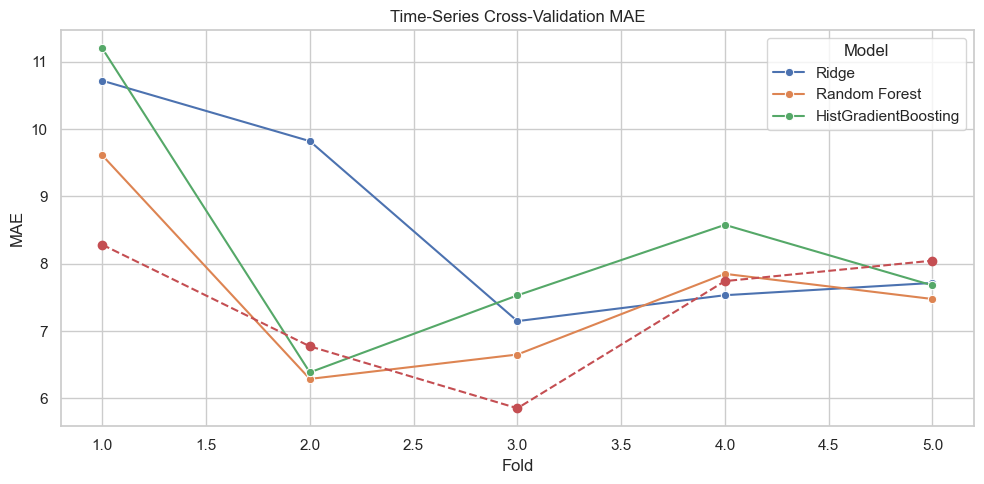

In [40]:
plt.figure(
    figsize=(10, 5)
)

sns.lineplot(
    data=cv_fold_results,
    x='Fold',
    y='MAE',
    hue='Model',
    marker='o'
)

plt.plot(
    baseline_cv[
        'fold'
    ],
    baseline_cv[
        'MAE'
    ],
    marker='o',
    linestyle='--',
    label='Persistence'
)

plt.title(
    'Time-Series Cross-Validation MAE'
)

plt.ylabel('MAE')

plt.tight_layout()
plt.show()

## Validation evaluation

In [41]:
#validation prediction
validation_predictions = pd.DataFrame(
    index=validation_df.index
)

validation_predictions[
    'actual'
] = y_validation

validation_predictions[
    'Persistence_24h'
] = validation_df[
    'baseline_persistence'
]

In [42]:
for model_name, estimator in (
    best_estimators.items()
):

    validation_predictions[
        model_name
    ] = estimator.predict(
        X_validation
    )

In [43]:
#validation metrics
validation_results = []

persistence_validation_metrics = (
    regression_metrics(
        y_validation,
        validation_predictions[
            'Persistence_24h'
        ]
    )
)

In [44]:
validation_results.append({
    'Model':
        'Persistence_24h',

    **persistence_validation_metrics,

    'MAE_Skill':
        0.0,

    'RMSE_Skill':
        0.0
})

In [45]:
for model_name in (
    best_estimators.keys()
):

    metrics = regression_metrics(
        y_validation,
        validation_predictions[
            model_name
        ]
    )

    metrics = add_skill_scores(
        metrics,
        persistence_validation_metrics
    )

    validation_results.append({
        'Model':
            model_name,

        **metrics
    })

In [46]:
validation_results = pd.DataFrame(
    validation_results
)

In [47]:
validation_results.sort_values(
    'MAE'
).round(4)

,Model,MAE,RMSE,R2,MAE_Skill,RMSE_Skill
0,Persistence_24h,7.2119,10.9124,0.8009,0.0000,0.0000
1,Ridge,7.2242,11.1196,0.7933,-0.0017,-0.0190
2,Random Forest,7.9029,13.3589,0.7016,-0.0958,-0.2242
3,HistGradientBoosting,8.2347,13.9565,0.6743,-0.1418,-0.2790


## Validation visualization

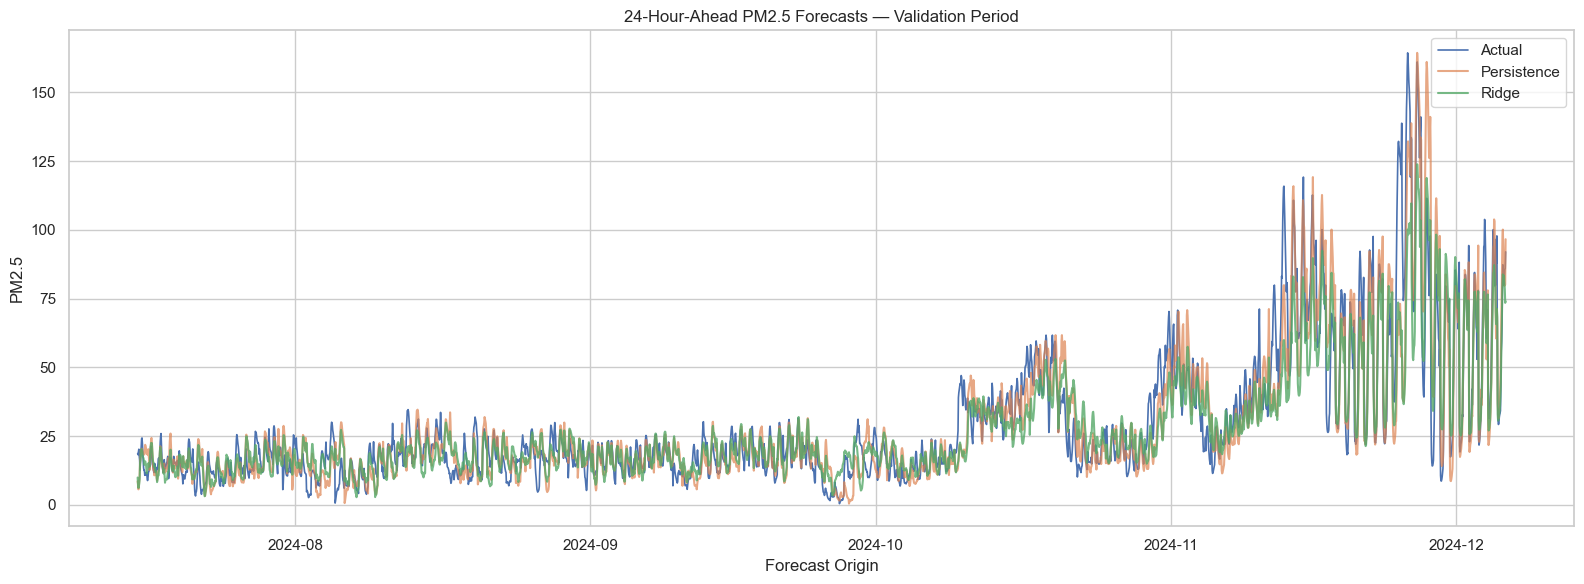

In [48]:
plt.figure(
    figsize=(16, 6)
)

plt.plot(
    validation_predictions.index,
    validation_predictions[
        'actual'
    ],
    label='Actual',
    linewidth=1.2
)

plt.plot(
    validation_predictions.index,
    validation_predictions[
        'Persistence_24h'
    ],
    label='Persistence',
    alpha=0.7
)

best_validation_ml = (
    validation_results[
        validation_results[
            'Model'
        ] != 'Persistence_24h'
    ]
    .sort_values(
        'MAE'
    )
    .iloc[0][
        'Model'
    ]
)

plt.plot(
    validation_predictions.index,
    validation_predictions[
        best_validation_ml
    ],
    label=best_validation_ml,
    alpha=0.8
)

plt.title(
    '24-Hour-Ahead PM2.5 Forecasts — Validation Period'
)

plt.xlabel('Forecast Origin')
plt.ylabel('PM2.5')

plt.legend()

plt.tight_layout()
plt.show()

In [49]:
#shorter period
zoom = (
    validation_predictions
    .iloc[:24 * 14]
)

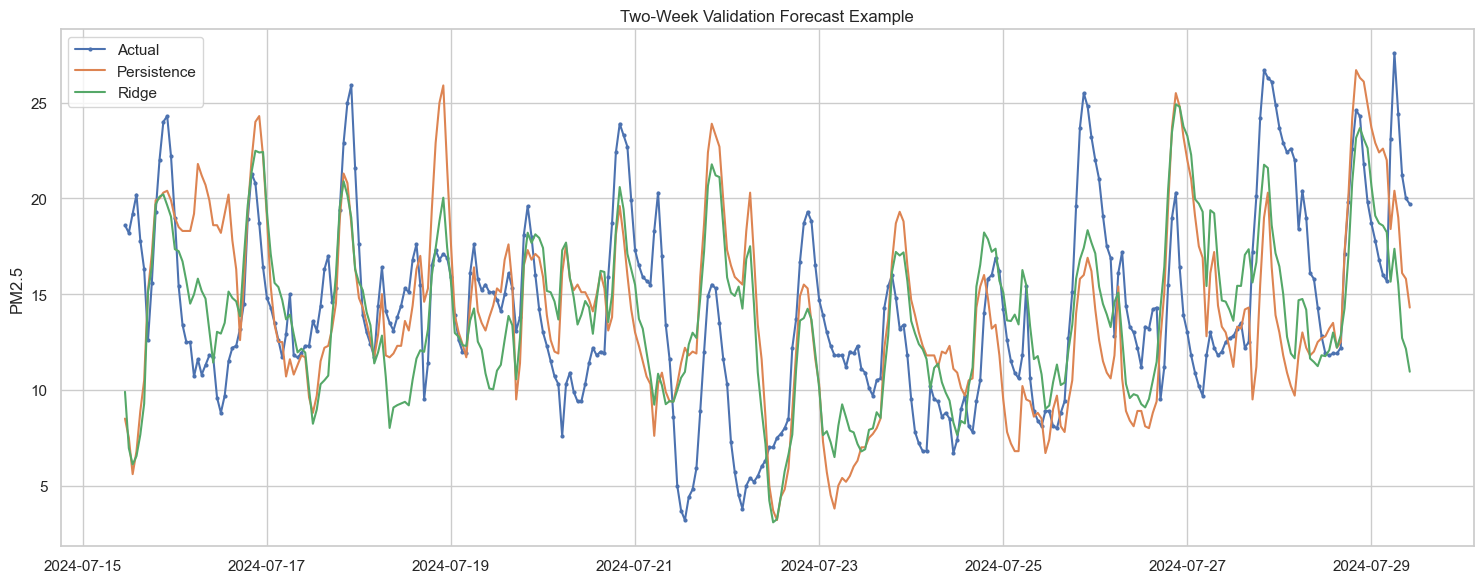

In [50]:
#two weeks
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    zoom.index,
    zoom['actual'],
    marker='o',
    markersize=2,
    label='Actual'
)

plt.plot(
    zoom.index,
    zoom[
        'Persistence_24h'
    ],
    label='Persistence'
)

plt.plot(
    zoom.index,
    zoom[
        best_validation_ml
    ],
    label=best_validation_ml
)

plt.title(
    'Two-Week Validation Forecast Example'
)

plt.ylabel('PM2.5')

plt.legend()

plt.tight_layout()
plt.show()

## Actual vs predicted

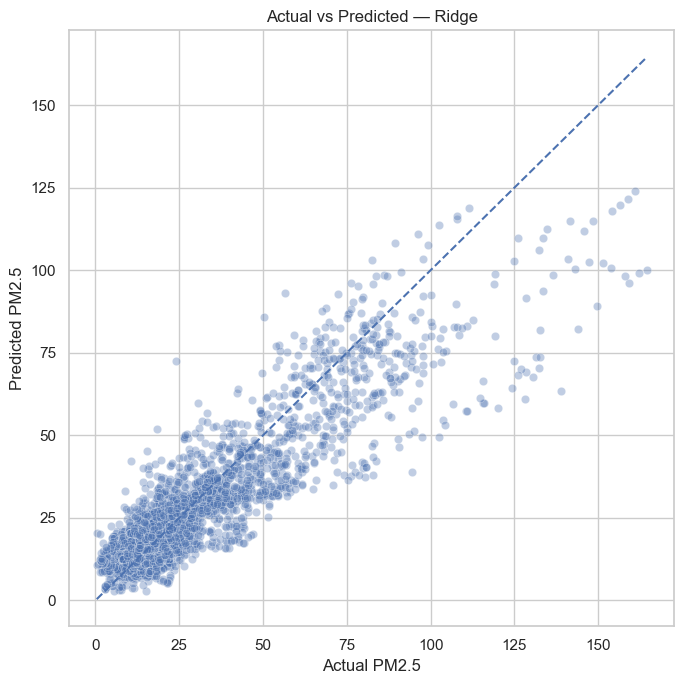

In [51]:
plt.figure(
    figsize=(7, 7)
)

sns.scatterplot(
    x=
        validation_predictions[
            'actual'
        ],

    y=
        validation_predictions[
            best_validation_ml
        ],

    alpha=0.35
)

min_value = min(
    validation_predictions[
        'actual'
    ].min(),

    validation_predictions[
        best_validation_ml
    ].min()
)

max_value = max(
    validation_predictions[
        'actual'
    ].max(),

    validation_predictions[
        best_validation_ml
    ].max()
)

plt.plot(
    [
        min_value,
        max_value
    ],
    [
        min_value,
        max_value
    ],
    linestyle='--'
)

plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5')

plt.title(
    f'Actual vs Predicted — '
    f'{best_validation_ml}'
)

plt.tight_layout()
plt.show()

## Formal model-selection table

In [52]:
#merge
selection_table = (
    validation_results
    .merge(
        cv_comparison[
            [
                'Model',
                'CV_MAE',
                'CV_MAE_SD',
                'CV_RMSE',
                'CV_R2'
            ]
        ],

        on='Model',
        how='left'
    )
)

In [53]:
selection_table = (
    selection_table[
        [
            'Model',
            'CV_MAE',
            'CV_MAE_SD',
            'CV_RMSE',
            'CV_R2',
            'MAE',
            'RMSE',
            'R2',
            'MAE_Skill',
            'RMSE_Skill'
        ]
    ]
    .rename(
        columns={
            'MAE':
                'Validation_MAE',

            'RMSE':
                'Validation_RMSE',

            'R2':
                'Validation_R2',

            'MAE_Skill':
                'Validation_MAE_Skill',

            'RMSE_Skill':
                'Validation_RMSE_Skill'
        }
    )
)

In [54]:
selection_table.sort_values(
    'Validation_MAE'
).round(4)

,Model,CV_MAE,CV_MAE_SD,CV_RMSE,CV_R2,Validation_MAE,Validation_RMSE,Validation_R2,Validation_MAE_Skill,Validation_RMSE_Skill
0,Persistence_24h,7.3389,1.0101,9.7963,0.4514,7.2119,10.9124,0.8009,0.0000,0.0000
1,Ridge,8.5867,1.4154,10.6820,0.3328,7.2242,11.1196,0.7933,-0.0017,-0.0190
2,Random Forest,7.5749,1.1610,9.6242,0.4710,7.9029,13.3589,0.7016,-0.0958,-0.2242
3,HistGradientBoosting,8.2738,1.6205,10.4786,0.3727,8.2347,13.9565,0.6743,-0.1418,-0.2790


In [55]:
ml_selection = (
    selection_table[
        selection_table[
            'Model'
        ] != 'Persistence_24h'
    ]
    .sort_values(
        'Validation_MAE'
    )
)

best_ml_name = (
    ml_selection
    .iloc[0][
        'Model'
    ]
)

best_ml_validation_mae = (
    ml_selection
    .iloc[0][
        'Validation_MAE'
    ]
)

persistence_validation_mae = (
    selection_table.loc[
        selection_table[
            'Model'
        ] == 'Persistence_24h',
        'Validation_MAE'
    ]
    .iloc[0]
)

print(
    "Best ML model:",
    best_ml_name
)

print(
    "Best ML validation MAE:",
    best_ml_validation_mae
)

print(
    "Persistence validation MAE:",
    persistence_validation_mae
)

Best ML model: Ridge
Best ML validation MAE: 7.224245247877503
Persistence validation MAE: 7.211909591422777


In [56]:
ml_beats_persistence = (
    best_ml_validation_mae
    <
    persistence_validation_mae
)

print(
    "Best ML beats persistence:",
    ml_beats_persistence
)

Best ML beats persistence: False


In [57]:
#estimator
selected_ml_estimator = (
    best_estimators[
        best_ml_name
    ]
)

In [58]:
print(
    "FROZEN ML MODEL:",
    best_ml_name
)

FROZEN ML MODEL: Ridge


## Refit using train + validation

In [59]:
#development dataset
development_df = pd.concat(
    [
        train_df,
        validation_df
    ]
).sort_index()

In [60]:
X_development = (
    development_df[
        feature_columns
    ]
)

y_development = (
    development_df[
        TARGET
    ]
)

In [61]:
#Final estimator
final_model = clone(
    selected_ml_estimator
)

In [62]:
final_model.fit(
    X_development,
    y_development
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](55,)","['pm25','pm10','no2',...,'target_dow_cos','target_doy_sin', 'target_doy_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,55
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


## Final locked test evaluation

In [63]:
#predict test
test_predictions = pd.DataFrame(
    index=test_df.index
)

test_predictions[
    'actual'
] = y_test

test_predictions[
    'Persistence_24h'
] = (
    test_df[
        'baseline_persistence'
    ]
)

test_predictions[
    best_ml_name
] = final_model.predict(
    X_test
)

In [64]:
#test metrics
test_persistence_metrics = (
    regression_metrics(
        y_test,
        test_predictions[
            'Persistence_24h'
        ]
    )
)

In [65]:
test_ml_metrics = (
    regression_metrics(
        y_test,
        test_predictions[
            best_ml_name
        ]
    )
)

In [66]:
test_ml_metrics = (
    add_skill_scores(
        test_ml_metrics,
        test_persistence_metrics
    )
)

In [67]:
#test comparison
test_results = pd.DataFrame([
    {
        'Model':
            'Persistence_24h',

        **test_persistence_metrics,

        'MAE_Skill':
            0.0,

        'RMSE_Skill':
            0.0
    },

    {
        'Model':
            best_ml_name,

        **test_ml_metrics
    }
])

In [68]:
test_results.round(4)

,Model,MAE,RMSE,R2,MAE_Skill,RMSE_Skill
0,Persistence_24h,12.0852,16.2844,0.7376,0.0000,0.0000
1,Ridge,11.3141,15.0277,0.7765,0.0638,0.0772


In [69]:
#Generalization gap
selected_validation_metrics = (
    validation_results.loc[
        validation_results[
            'Model'
        ] == best_ml_name
    ]
    .iloc[0]
)

In [70]:
generalization_summary = pd.DataFrame({
    'Validation': {
        'MAE':
            selected_validation_metrics[
                'MAE'
            ],

        'RMSE':
            selected_validation_metrics[
                'RMSE'
            ],

        'R2':
            selected_validation_metrics[
                'R2'
            ]
    },

    'Test': {
        'MAE':
            test_ml_metrics[
                'MAE'
            ],

        'RMSE':
            test_ml_metrics[
                'RMSE'
            ],

        'R2':
            test_ml_metrics[
                'R2'
            ]
    }
})

generalization_summary.round(3)

,Validation,Test
MAE,7.224,11.314
RMSE,11.120,15.028
R2,0.793,0.777


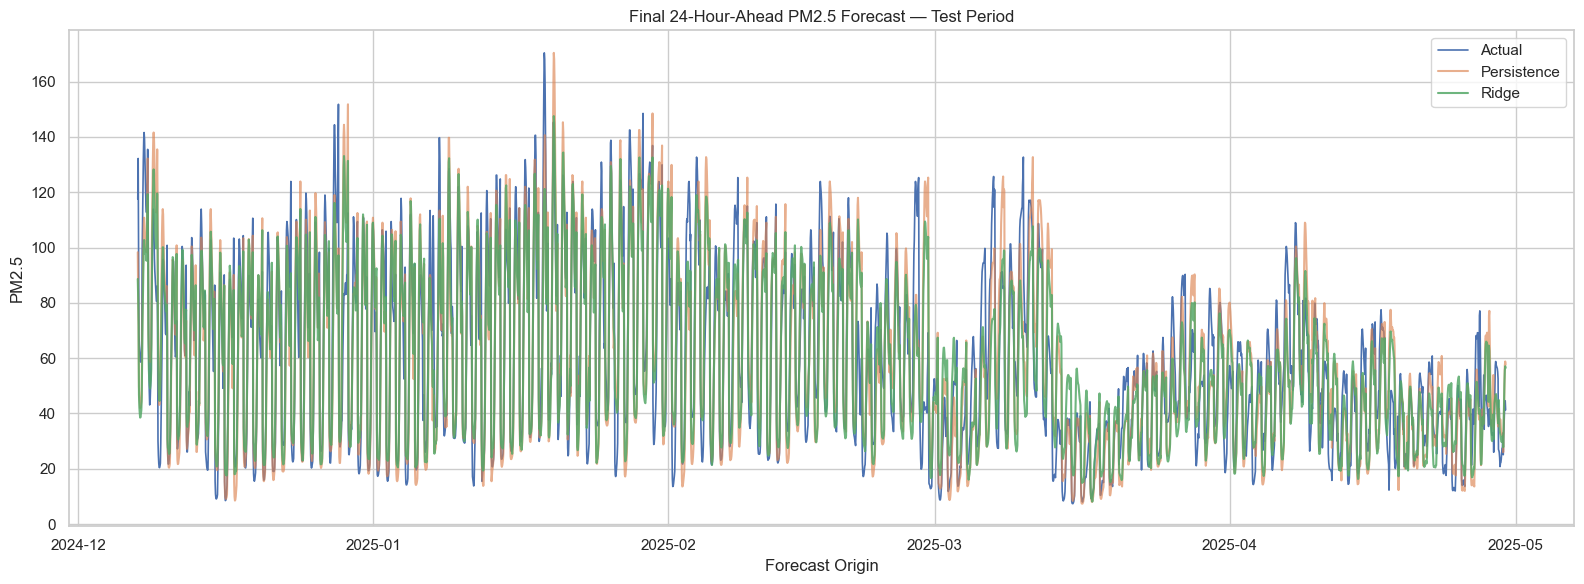

In [71]:
#testo visualization
plt.figure(
    figsize=(16, 6)
)

plt.plot(
    test_predictions.index,
    test_predictions[
        'actual'
    ],
    label='Actual',
    linewidth=1.2
)

plt.plot(
    test_predictions.index,
    test_predictions[
        'Persistence_24h'
    ],
    label='Persistence',
    alpha=0.65
)

plt.plot(
    test_predictions.index,
    test_predictions[
        best_ml_name
    ],
    label=best_ml_name,
    alpha=0.85
)

plt.title(
    'Final 24-Hour-Ahead PM2.5 Forecast — Test Period'
)

plt.xlabel('Forecast Origin')
plt.ylabel('PM2.5')

plt.legend()

plt.tight_layout()
plt.show()

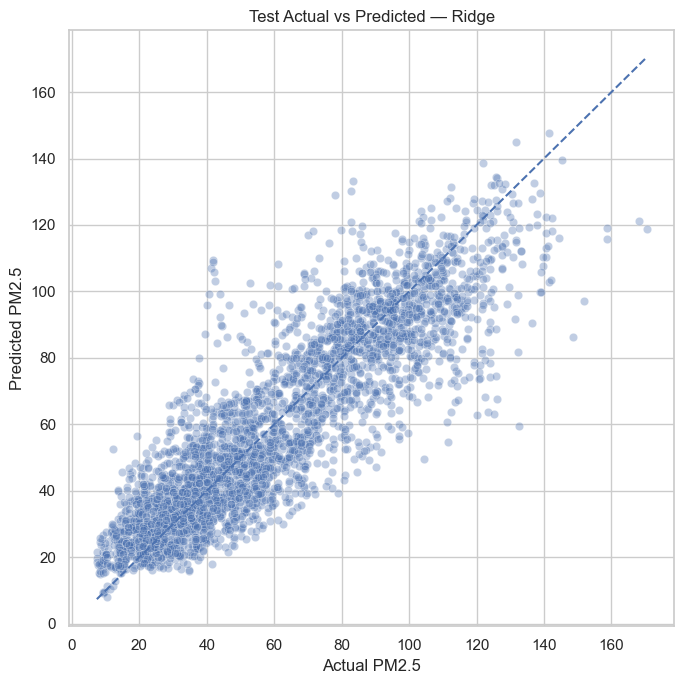

In [72]:
# actual vs predicted
plt.figure(
    figsize=(7, 7)
)

sns.scatterplot(
    x=
        test_predictions[
            'actual'
        ],

    y=
        test_predictions[
            best_ml_name
        ],

    alpha=0.35
)

min_value = min(
    test_predictions[
        'actual'
    ].min(),

    test_predictions[
        best_ml_name
    ].min()
)

max_value = max(
    test_predictions[
        'actual'
    ].max(),

    test_predictions[
        best_ml_name
    ].max()
)

plt.plot(
    [
        min_value,
        max_value
    ],
    [
        min_value,
        max_value
    ],
    linestyle='--'
)

plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5')

plt.title(
    f'Test Actual vs Predicted — '
    f'{best_ml_name}'
)

plt.tight_layout()
plt.show()

In [73]:
model_filename = (
    best_ml_name
    .lower()
    .replace(
        ' ',
        '_'
    )
)

In [74]:
joblib.dump(
    final_model,
    MODELS_DIR /
    f'{model_filename}_24h.joblib'
)

['../models/phase9/ridge_24h.joblib']

In [75]:
#validation predictions
validation_predictions.to_csv(
    TABLES_DIR /
    "validation_predictions.csv"
)

In [76]:
test_predictions.to_csv(
    TABLES_DIR /
    "test_predictions.csv"
)

In [77]:
cv_comparison.to_csv(
    TABLES_DIR /
    "cv_model_comparison.csv",
    index=False
)

cv_fold_results.to_csv(
    TABLES_DIR /
    "cv_fold_results.csv",
    index=False
)

selection_table.to_csv(
    TABLES_DIR /
    "model_selection.csv",
    index=False
)

test_results.to_csv(
    TABLES_DIR /
    "final_test_results.csv",
    index=False
)

generalization_summary.to_csv(
    TABLES_DIR /
    "generalization_summary.csv"
)

In [78]:
print("=" * 78)
print(
    "PHASE 9 — MACHINE LEARNING MODEL COMPARISON"
)
print("=" * 78)


print("\nCROSS-VALIDATION COMPARISON")

print(
    cv_comparison
    .sort_values(
        'CV_MAE'
    )
    .round(3)
)


print("\nVALIDATION MODEL SELECTION")

print(
    selection_table
    .sort_values(
        'Validation_MAE'
    )
    .round(4)
)


print(
    "\nFrozen ML model:",
    best_ml_name
)

print(
    "Beats persistence on validation:",
    ml_beats_persistence
)


print("\nFINAL LOCKED TEST RESULTS")

print(
    test_results
    .sort_values(
        'MAE'
    )
    .round(4)
)


print("\nGENERALIZATION")

print(
    generalization_summary
    .round(3)
)


print("\nBEST PARAMETERS")

print(
    "\nRidge:"
)

print(
    ridge_search.best_params_
)

print(
    "\nRandom Forest:"
)

print(
    rf_search.best_params_
)

print(
    "\nHistGradientBoosting:"
)

print(
    hgb_search.best_params_
)


print("\n" + "=" * 78)

PHASE 9 — MACHINE LEARNING MODEL COMPARISON

CROSS-VALIDATION COMPARISON
                  Model  CV_MAE  CV_MAE_SD  CV_RMSE  CV_R2
0       Persistence_24h   7.339      1.010    9.796  0.451
2         Random Forest   7.575      1.161    9.624  0.471
3  HistGradientBoosting   8.274      1.621   10.479  0.373
1                 Ridge   8.587      1.415   10.682  0.333

VALIDATION MODEL SELECTION
                  Model  CV_MAE  CV_MAE_SD  CV_RMSE   CV_R2  Validation_MAE  \
0       Persistence_24h  7.3389     1.0101   9.7963  0.4514          7.2119   
1                 Ridge  8.5867     1.4154  10.6820  0.3328          7.2242   
2         Random Forest  7.5749     1.1610   9.6242  0.4710          7.9029   
3  HistGradientBoosting  8.2738     1.6205  10.4786  0.3727          8.2347   

   Validation_RMSE  Validation_R2  Validation_MAE_Skill  Validation_RMSE_Skill  
0          10.9124         0.8009                0.0000                 0.0000  
1          11.1196         0.7933             

## Phase 9 Summary: Machine-Learning Forecasting

Three machine-learning models were evaluated for 24-hour-ahead PM2.5
forecasting: Ridge regression, Random Forest regression, and Histogram
Gradient Boosting. All models were tuned exclusively using five-fold
expanding-window time-series cross-validation with a 24-hour purge gap.

The 24-hour persistence forecast proved to be a particularly strong
benchmark. Across the cross-validation folds, persistence achieved the
lowest mean absolute error (MAE) of approximately 7.34. Random Forest was
the strongest machine-learning model by cross-validation MAE
(approximately 7.57) and achieved slightly better average RMSE and R²
than persistence, although its MAE remained higher.

On the independent chronological validation period, persistence again
achieved the lowest MAE at approximately 7.21. Ridge regression performed
nearly identically, with an MAE of approximately 7.22, whereas Random
Forest and Histogram Gradient Boosting performed less favorably.
Therefore, none of the evaluated machine-learning models demonstrated a
clear improvement over persistence during model-development evaluation.

Among the machine-learning candidates, Ridge regression produced the
lowest validation MAE and was consequently frozen as the final ML model
before the held-out test period was examined. The selected model used a
regularization parameter of alpha = 100.

The held-out test period represented a substantially higher-pollution
regime than the training and validation periods. On this challenging
future period, Ridge achieved an MAE of approximately 11.31, RMSE of
15.03, and R² of 0.777. The 24-hour persistence baseline achieved an MAE
of approximately 12.09, RMSE of 16.28, and R² of 0.738.

Thus, the frozen Ridge model reduced test MAE by approximately 6.4% and
RMSE by approximately 7.7% relative to persistence. This improvement was
obtained without using test data for model or hyperparameter selection.

The results show that persistence is exceptionally difficult to improve
upon under typical historical conditions, reflecting the strong
24-hour temporal structure identified earlier in the project. However,
the multivariable Ridge model generalized somewhat better during the
shifted high-pollution test regime, indicating that lagged pollution,
meteorological history, co-pollutants, and calendar information may
provide incremental forecasting value when pollution conditions differ
substantially from the model-development period.

Visual inspection additionally suggests that Ridge tends to underpredict
the highest PM2.5 concentrations. Therefore, aggregate forecasting
metrics alone are insufficient for assessing operational performance.
Subsequent error analysis will specifically examine forecast performance
during winter, extreme pollution events, and high-concentration regimes.

In [79]:
print(
    cv_comparison
    .sort_values('CV_MAE')
    .round(3)
)

print(
    selection_table
    .sort_values('Validation_MAE')
    .round(4)
)

print(
    test_results
    .sort_values('MAE')
    .round(4)
)

print(
    generalization_summary
    .round(3)
)

print(
    ridge_search.best_params_
)

print(
    rf_search.best_params_
)

print(
    hgb_search.best_params_
)

                  Model  CV_MAE  CV_MAE_SD  CV_RMSE  CV_R2
0       Persistence_24h   7.339      1.010    9.796  0.451
2         Random Forest   7.575      1.161    9.624  0.471
3  HistGradientBoosting   8.274      1.621   10.479  0.373
1                 Ridge   8.587      1.415   10.682  0.333
                  Model  CV_MAE  CV_MAE_SD  CV_RMSE   CV_R2  Validation_MAE  \
0       Persistence_24h  7.3389     1.0101   9.7963  0.4514          7.2119   
1                 Ridge  8.5867     1.4154  10.6820  0.3328          7.2242   
2         Random Forest  7.5749     1.1610   9.6242  0.4710          7.9029   
3  HistGradientBoosting  8.2738     1.6205  10.4786  0.3727          8.2347   

   Validation_RMSE  Validation_R2  Validation_MAE_Skill  Validation_RMSE_Skill  
0          10.9124         0.8009                0.0000                 0.0000  
1          11.1196         0.7933               -0.0017                -0.0190  
2          13.3589         0.7016               -0.0958           

In [80]:
generalization_summary = pd.DataFrame({
    'Validation': {
        'MAE':
            selected_validation_metrics['MAE'],

        'RMSE':
            selected_validation_metrics['RMSE'],

        'R2':
            selected_validation_metrics['R2']
    },

    'Test': {
        'MAE':
            test_ml_metrics['MAE'],

        'RMSE':
            test_ml_metrics['RMSE'],

        'R2':
            test_ml_metrics['R2']
    }
})

generalization_summary.round(3)

,Validation,Test
MAE,7.224,11.314
RMSE,11.120,15.028
R2,0.793,0.777
